## Eazy Diner
> Analysis on restaurants in different cities

### Data Cleaning

#### Importing Libraries

In [5]:
# Importing essential Python libraries for data handling and visualization.
import pandas as pd
import numpy as np
import re

Pandas is used for data handling.

NumPy is used for calculations, and visualization libraries help in understanding data through graphs.

#### Loading the Dataset

In [6]:
df = pd.read_csv("Eazy_Diner.csv")
df_clean = df.copy()
df_clean.head()

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,delhi-ncr,"Connaught Place (CP), Central Delhi",Indian,₹1300 for two,4.1
1,Hard Rock Cafe,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,₹1500 for two,4.0
2,Cafe Out of the Box Courtyard,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,₹1200 for two,3.9
3,Sakura,delhi-ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",₹4500 for two,4.0
4,Shang Palace,delhi-ncr,Shangri-La Eros New Delhi,Chinese,₹3000 for two,4.5


Loaded the scraped EazyDiner data into the notebook.

Converted raw data into a structured DataFrame.

This step makes the data ready for analysis.

#### Checking Data Information

In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17022 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  17022 non-null  object 
 1   City             17022 non-null  object 
 2   Area             17022 non-null  object 
 3   Cuisine Type     16975 non-null  object 
 4   Cost for Two     17022 non-null  object 
 5   Ratings          17011 non-null  float64
dtypes: float64(1), object(5)
memory usage: 798.0+ KB


The dataset has 17,022 restaurants with mostly complete and well-structured data, making it reliable for analysis.

In [4]:
df_clean.describe()

,Ratings
count,17011.000000
mean,4.122750
std,0.707793
min,1.000000
25%,4.000000
50%,4.000000
75%,4.500000
max,5.000000


The average rating is about 4.1, showing that most restaurants are rated positively by customers.

#### Convert Currency (AED → INR)

In [8]:
# Conversion rate
conversion_rate = 24.18  # 1 AED = 

def clean_cost(value):
    if isinstance(value, str):
        # Step 1: Convert AED → INR
        if "AED" in value.upper():
            num = re.sub(r'[^\d.]', '', value)  # extract numeric part
            if num:
                value = str(float(num) * conversion_rate)  # convert to INR
        
        # Step 2: Remove all special characters and text
        value = re.sub(r'[^\d]', '', value)  # keep only digits
        return value if value else None
    
    return None

# Apply the function
df_clean['Cost for Two'] = df_clean['Cost for Two'].apply(clean_cost)

# Convert to integer
df_clean['Cost for Two'] = pd.to_numeric(df_clean['Cost for Two'], errors='coerce').astype('Int64')

# Verify result
print(df_clean[['Restaurant Name', 'City', 'Cost for Two']].tail(10))
print(df_clean.dtypes)

                Restaurant Name   City  Cost for Two
17012            Emperor Lounge  dubai         29016
17013         Peshwa Restaurant  dubai         26598
17014                    Masaya  dubai         44733
17015              Palm Kitchen  dubai         84630
17016       Aashi's Food Corner  dubai         19344
17017       New Silver Paradise  dubai         24180
17018      Anaarkali Restaurant  dubai         24180
17019         Zaam’s Restaurant  dubai         16926
17020  Layali Aldhan Restaurant  dubai         29016
17021            Roaring Rabbit  dubai         53196
Restaurant Name     object
City                object
Area                object
Cuisine Type        object
Cost for Two         Int64
Ratings            float64
dtype: object


A conversion rate is defined to convert AED prices into INR for consistency.

A function is created to clean the cost values by removing text and special characters.

AED prices are converted into Indian Rupees using the defined conversion rate.

Only numeric values are retained to make the cost column analysis-ready.

The cleaning function is applied to the “Cost for Two” column.

The cleaned cost values are converted into numeric format for calculations.

The final output is printed to verify that cost data is cleaned correctly.

In [9]:
df_clean

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,delhi-ncr,"Connaught Place (CP), Central Delhi",Indian,1300,4.1
1,Hard Rock Cafe,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1500,4.0
2,Cafe Out of the Box Courtyard,delhi-ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1200,3.9
3,Sakura,delhi-ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",4500,4.0
4,Shang Palace,delhi-ncr,Shangri-La Eros New Delhi,Chinese,3000,4.5
...,...,...,...,...,...,...
17017,New Silver Paradise,dubai,Rove Downtown Dubai,Indian,24180,4.0
17018,Anaarkali Restaurant,dubai,"Al Karama, Dubai",Multicuisine,24180,4.0
17019,Zaam’s Restaurant,dubai,"Al Hamriya, Dubai, Dubai",Indian,16926,4.0
17020,Layali Aldhan Restaurant,dubai,"Al Barsha, Dubai","Egyptian, Arabian",29016,4.0


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17022 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  17022 non-null  object 
 1   City             17022 non-null  object 
 2   Area             17022 non-null  object 
 3   Cuisine Type     16975 non-null  object 
 4   Cost for Two     17022 non-null  Int64  
 5   Ratings          17011 non-null  float64
dtypes: Int64(1), float64(1), object(4)
memory usage: 814.7+ KB


#### Fixing Incorrect Data Formats

In [8]:
df_clean['Ratings'] = pd.to_numeric(df_clean['Ratings'])

Ratings are converted into numeric format to enable accurate calculations and analysis.

#### Clean Text Columns

In [9]:
df_clean['City'] = df_clean['City'].str.title().str.strip()
df_clean['Restaurant Name'] = df_clean['Restaurant Name'].str.strip()
df_clean['Area'] = df_clean['Area'].str.strip()

City names are standardized using proper capitalization for consistency.

Extra spaces are removed from restaurant names and area names to avoid duplicate entries.

#### Identify Missing Values

In [10]:
df_clean.isnull().sum()

Restaurant Name     0
City                0
Area                0
Cuisine Type       47
Cost for Two        0
Ratings            11
dtype: int64

Missing values are checked to understand data completeness.

Only a few missing values are found, showing the dataset is mostly clean and reliable.

#### Treat Missing Values

In [11]:
df_clean['Ratings'] = df_clean['Ratings'].fillna(df_clean['Ratings'].median())
# Fill missing categorical values with mode
df_clean['Cuisine Type'] = df_clean['Cuisine Type'].fillna(df_clean['Cuisine Type'].mode()[0])

Missing ratings are filled using the median value to avoid the effect of outliers.

Missing cuisine types are filled using the most frequent value (mode) to maintain consistency.

In [12]:
df_clean.isnull().sum()

Restaurant Name    0
City               0
Area               0
Cuisine Type       0
Cost for Two       0
Ratings            0
dtype: int64

After treatment, no missing values remain, confirming the dataset is fully cleaned.

#### Checking If any duplicates

In [13]:
df_clean.duplicated().sum()

np.int64(121)

The dataset contains 121 duplicate records, which can affect analysis accuracy.

#### Removing/Dropping Duplicates

In [11]:
df_clean.drop_duplicates(inplace=True)

Duplicate entries are removed to ensure each restaurant record is unique.

#### Rechecking

In [15]:
df_clean.duplicated().sum()

np.int64(0)

After removal, no duplicate records remain, confirming successful data cleaning.

#### Identify Outliers (IQR Method)

The IQR method is used to identify unusually high or low cost values in the dataset.

In [16]:
Q1 = df_clean['Cost for Two'].quantile(0.25)
Q3 = df_clean['Cost for Two'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower limit:",lower_limit)
print("Upper limit:",upper_limit)

Lower limit: -950.0
Upper limit: 3450.0


Any cost value below −950 or above 3450 is considered an outlier.

#### Treat Outliers (Capping)

Extreme cost values are capped within acceptable limits to prevent skewed analysis.

In [17]:
df_clean['Cost for Two'] = np.where(df_clean['Cost for Two'] > upper_limit, upper_limit, df_clean['Cost for Two'])
df_clean['Cost for Two'] = np.where(df_clean['Cost for Two'] < lower_limit, lower_limit, df_clean['Cost for Two'])

Outlier treatment ensures balanced and realistic cost analysis.

#### Final Check

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16901 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  16901 non-null  object 
 1   City             16901 non-null  object 
 2   Area             16901 non-null  object 
 3   Cuisine Type     16901 non-null  object 
 4   Cost for Two     16901 non-null  float64
 5   Ratings          16901 non-null  float64
dtypes: float64(2), object(4)
memory usage: 924.3+ KB


In [19]:
df_clean['Cost for Two'] = df_clean['Cost for Two'].astype('int')

The cost values are converted to integer format to make analysis and visualization simpler.

In [20]:
df_clean.describe()

,Cost for Two,Ratings
count,16901.000000,16901.000000
mean,1310.493521,4.123490
std,796.854317,0.709992
min,7.000000,1.000000
25%,700.000000,4.000000
50%,1080.000000,4.000000
75%,1800.000000,4.500000
max,3450.000000,5.000000


In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16901 entries, 0 to 17021
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  16901 non-null  object 
 1   City             16901 non-null  object 
 2   Area             16901 non-null  object 
 3   Cuisine Type     16901 non-null  object 
 4   Cost for Two     16901 non-null  int64  
 5   Ratings          16901 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 924.3+ KB


In [22]:
df_clean.to_csv("Eazy_Diner_Cleaned.csv", index=False)

After cleaning and standardization, the refined dataset is saved as Eazy_Diner_Cleaned.csv for reliable analysis.

The project maintains both raw and cleaned datasets, ensuring transparency and reproducibility in the data analysis process.

In [6]:
df1 = pd.read_csv("Eazy_Diner_Cleaned.csv")
df1

,Restaurant Name,City,Area,Cuisine Type,Cost for Two,Ratings
0,Desi Villagio,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Indian,1300,4.1
1,Hard Rock Cafe,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1500,4.0
2,Cafe Out of the Box Courtyard,Delhi-Ncr,"Connaught Place (CP), Central Delhi",Multicuisine,1200,3.9
3,Sakura,Delhi-Ncr,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",3450,4.0
4,Shang Palace,Delhi-Ncr,Shangri-La Eros New Delhi,Chinese,3000,4.5
...,...,...,...,...,...,...
17017,New Silver Paradise,Dubai,Rove Downtown Dubai,Indian,3450,4.0
17018,Anaarkali Restaurant,Dubai,"Al Karama, Dubai",Multicuisine,3450,4.0
17019,Zaam’s Restaurant,Dubai,"Al Hamriya, Dubai, Dubai",Indian,3450,4.0
17020,Layali Aldhan Restaurant,Dubai,"Al Barsha, Dubai","Egyptian, Arabian",3450,4.0


In [24]:
# Convert to string (handles NaN or list-like entries)
df1['Cuisine Type'] = df1['Cuisine Type'].astype(str)

# Expand tab characters (\t) into spaces (safe even if no tabs exist)
df1['Cuisine Type'] = df1['Cuisine Type'].apply(
    lambda x: x.expandtabs() if isinstance(x, str) else x
)

# Remove brackets, quotes, and backslashes
df1['Cuisine Type'] = (
    df1['Cuisine Type']
    .str.replace(r"[\[\]'\"\\]", '', regex=True)  # remove [ ] ' " \
    .str.strip()
)

# Split multiple cuisines into lists
df1['Cuisine Type'] = df1['Cuisine Type'].apply(
    lambda x: [i.strip() for i in x.split(',') if i.strip() != '']
)

# Explode the list to create one row per cuisine
df1 = df1.explode('Cuisine Type')

# Build pivot table safely
pivot_table = pd.pivot_table(
    df1,
    values='Ratings',
    index='Cuisine Type',
    columns='City',
    aggfunc='mean'
)
pivot_table


City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


### Data Visualizations

### UNIVARIATE ANALYSIS
- Purpose: Understand individual column behavior.


#### Numerical (Cost for Two, Ratings)
**Descriptive Statistics (Non-Visual)**

In [25]:
# Statistical Summary
df1[['Cost for Two', 'Ratings']].describe()

,Cost for Two,Ratings
count,21094.000000,21094.000000
mean,1318.800038,4.127193
std,801.590572,0.706778
min,7.000000,1.000000
25%,700.000000,4.000000
50%,1100.000000,4.000000
75%,1800.000000,4.500000
max,3450.000000,5.000000


In [26]:
df1["Cost for Two"].skew(), df1["Ratings"].skew() # Skewness

(np.float64(1.0847701792114983), np.float64(-2.0836895820935912))

In [27]:
df1["Cost for Two"].kurt(), df1["Ratings"].kurt() # Kurtosis

(np.float64(0.6763035409961264), np.float64(7.030299314665967))

**Interpretation:**
+ Skewness tells if data is left or right skewed.
+ Kurtosis shows if distribution is peaked or flat.
+ Mean vs Median difference shows outliers.

#### Cateogrical (City)

In [28]:
df1['City'].value_counts(normalize=True)  # Proportion

City
Bengaluru             0.123163
Delhi-Ncr             0.114677
Mumbai                0.111975
Hyderabad             0.062909
Pune                  0.051342
Kolkata               0.050204
Chennai               0.048971
Jaipur                0.045842
Chandigarh-Tricity    0.043519
Goa                   0.037072
Dubai                 0.034939
Ahmedabad             0.029582
Lucknow               0.028207
Udaipur               0.022186
Mangalore-Tricity     0.021428
Indore                0.020385
Patna                 0.020290
Mysuru                0.018915
Vadodara              0.015786
Kochi                 0.012800
Amritsar              0.012326
Coimbatore            0.012089
Bhubaneswar           0.011472
Ranchi                0.009576
Thiruvananthapuram    0.009292
Ludhiana              0.008107
Nagpur                0.007016
Visakhapatnam         0.006590
Agra                  0.006400
Madurai               0.001991
Abu-Dhabi             0.000948
Name: proportion, dtype: float64

In [29]:
df1['Cuisine Type'].mode()

0    Multicuisine
Name: Cuisine Type, dtype: object

### Visualizations
> Data visualizations are created to better understand patterns and trends in the dataset.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Visualization libraries are imported and styled to create clear and professional-looking graphs.

#### Histogram (Cost for Two)

- A histogram plot is a graphical representation used to visualize the distribution of numerical data.

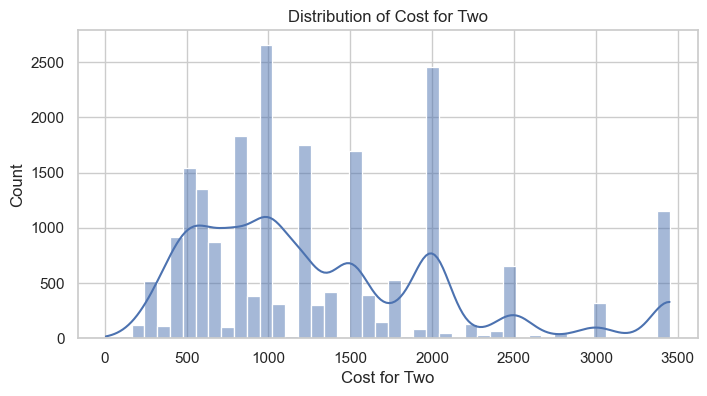

In [31]:
plt.figure(figsize=(8,4))
sns.histplot(df1['Cost for Two'], kde=True)
plt.title("Distribution of Cost for Two")
plt.show()

Most restaurants fall in the ₹500 to ₹2000 range, indicating that the majority are mid-range and affordable dining options.

The peak around ₹900–₹1200 suggests this is the most common spending range for customers.

There are fewer restaurants above ₹2500, showing that premium or luxury dining options are limited.

The distribution is slightly right-skewed, meaning a small number of high-cost restaurants increase the overall spread of prices.

#### Histogram (Ratings)

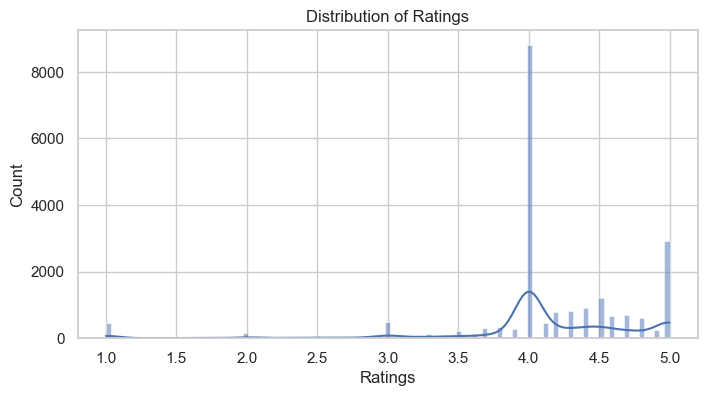

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(df1["Ratings"], kde=True)
plt.title("Distribution of Ratings")
plt.show()

Most restaurants have ratings between 4.0 and 4.5, showing generally high customer satisfaction.

The highest concentration is around 4.0, indicating it is the most common rating.

Very few restaurants have ratings below 3.0, which means poorly rated restaurants are limited.

The distribution is slightly left-skewed, suggesting that lower ratings are rare compared to higher ratings.

#### Box Plot (Cost for Two)

- A box plot is used to summarize the distribution of data and detect outliers using quartiles.

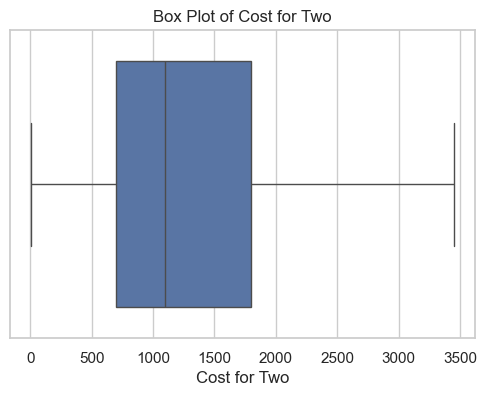

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df1['Cost for Two'])
plt.title("Box Plot of Cost for Two")
plt.show()

The middle line inside the box represents the median cost, showing the typical spending range for most customers.

The box area (IQR) represents where the majority of restaurant prices lie, indicating a concentrated mid-price segment.

The whiskers show the overall spread of cost values from minimum to maximum within the capped range.

The slightly longer upper side suggests that some restaurants are priced higher, but most remain in the moderate range.

#### Box Plot (Ratings)

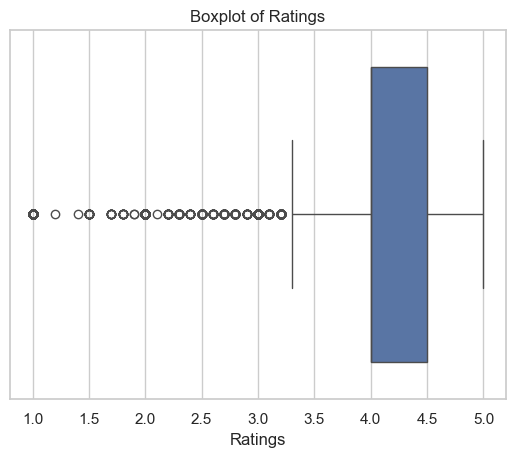

In [34]:
sns.boxplot(x=df1['Ratings'])
plt.title("Boxplot of Ratings")
plt.show()

The median rating is around 4.2–4.3, showing that most restaurants receive high customer ratings.

The box (IQR) lies mostly between 4.0 and 4.5, indicating that the majority of restaurants are consistently well-rated.

Several outliers appear on the lower side (below 3.5), representing a few poorly rated restaurants.

The concentration of values in the higher range confirms that customer satisfaction is generally strong across the platform.

#### KDE Plot [Cost for Two (Limited Range)]

- A KDE plot shows the smooth distribution pattern of data to understand where values are most concentrated.

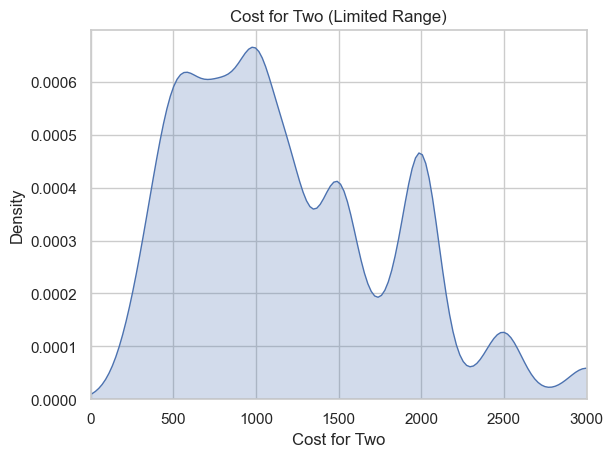

In [35]:
sns.kdeplot(df1["Cost for Two"], fill=True)
plt.xlim(0, 3000)  # Adjust range to focus on majority
plt.title("Cost for Two (Limited Range)")
plt.show()

The highest density peak appears around ₹800–₹1200, indicating this is the most common spending range.

A secondary concentration is visible around ₹1800–₹2000, suggesting a smaller premium segment.

Very low density beyond ₹2500 shows that high-cost restaurants are limited in number.

By limiting the range to ₹0–₹3000, the visualization clearly highlights the majority pricing trend without extreme values affecting the view.

#### KDE Plot [Cost for Two - Density Plot]

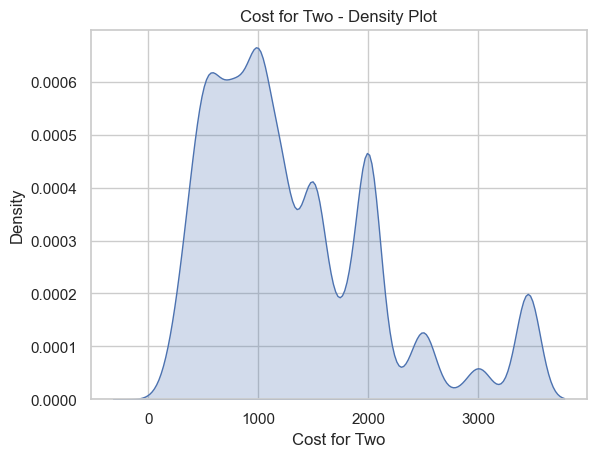

In [36]:
sns.kdeplot(df1["Cost for Two"], fill=True)
plt.title("Cost for Two - Density Plot")
plt.show()

The highest density peak is around ₹800–₹1200, indicating this is the most common spending range for customers.

A noticeable secondary peak appears around ₹1800–₹2000, showing a smaller premium dining segment.

The curve gradually decreases after ₹2500, meaning fewer restaurants fall in the high-cost category.

The overall shape is slightly right-skewed, indicating that a small number of expensive restaurants extend the upper range of prices.

#### Violin Plot (Ratings)

- A violin plot combines a box plot and density plot to show both data distribution and concentration levels.

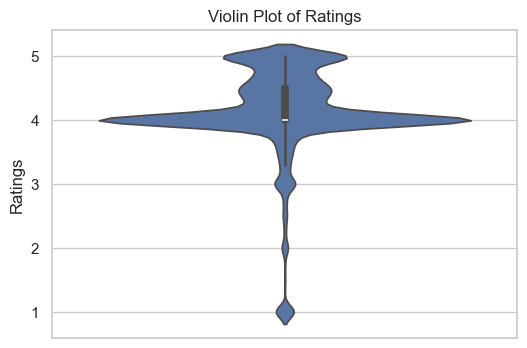

In [37]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df1['Ratings'])
plt.title("Violin Plot of Ratings")
plt.show()

The widest part of the violin is around 4.0–4.5, indicating that most restaurants have ratings in this range.

The median rating lies slightly above 4.0, showing overall strong customer satisfaction.

The narrow lower portion below 3.0 indicates that very few restaurants have low ratings.

The distribution is concentrated toward the higher end, confirming that most restaurants are well-rated.

### Categorical

#### Count Plot (Top 10 Cuisine Types)

- A count plot shows the frequency of categories to identify the most common groups in the dataset.

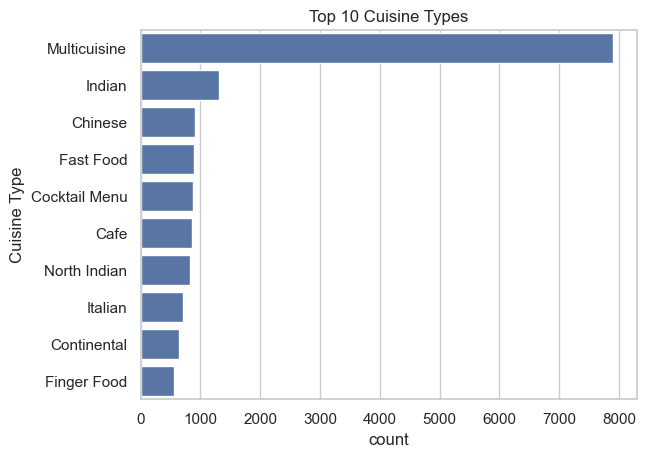

In [38]:
sns.countplot(
    data=df1.reset_index(drop=True),
    y='Cuisine Type',
    order=df1['Cuisine Type'].value_counts().head(10).index
)
plt.title("Top 10 Cuisine Types")
plt.show()

Multicuisine dominates significantly, indicating that most restaurants offer multiple cuisine options.

Indian cuisine is the second most common, showing strong local food preference.

Chinese, Fast Food, Cafe, and North Indian cuisines also appear frequently, indicating diverse customer choices.

Other cuisines like Italian, Continental, and Finger Food are present but in comparatively smaller numbers.

#### Count Plot (Top 10 Cities)

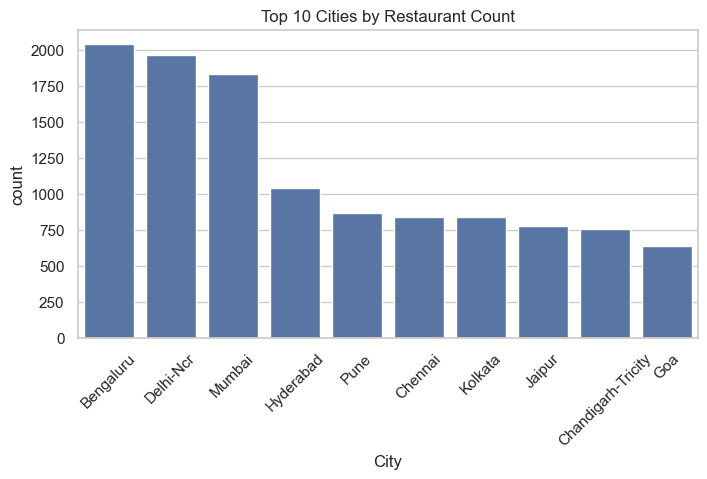

In [7]:
plt.figure(figsize=(8,4))
sns.countplot(data=df1.reset_index(drop=True), x="City", order=df1["City"].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Restaurant Count")
plt.show()

Bengaluru has the highest number of restaurants, indicating a strong and competitive food market.

Delhi-NCR and Mumbai follow closely, showing that major metropolitan cities dominate the restaurant industry.

Cities like Hyderabad, Pune, and Kolkata have moderate restaurant presence.

Smaller counts in cities like Jaipur, Chandigarh-Tricity, and Goa suggest comparatively smaller but active food markets.

#### Pie Chart (City Distribution)

A pie chart shows the percentage contribution of each category to the total.

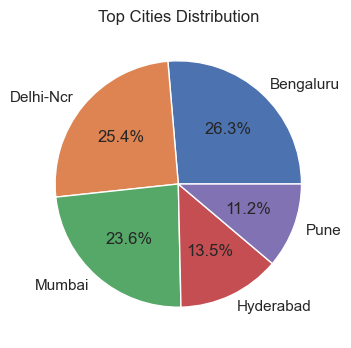

In [8]:
df1['City'].value_counts().head(5).plot.pie(autopct='%1.1f%%', figsize=(8,4))
plt.title("Top Cities Distribution")
plt.ylabel("")
plt.show()

Bengaluru contributes the highest share (~26.5%), indicating it has the largest restaurant presence among top cities.

Delhi-NCR (~24.7%) and Mumbai (~24.1%) follow closely, showing strong competition among major metro cities.

Hyderabad (~13.6%) and Pune (~11.1%) contribute smaller but significant portions.

The chart clearly highlights that the restaurant market is dominated by major metropolitan cities.

### BIVARIATE / MULTIVARIATE ANALYSIS

#### Numerical - Numerical (Cost for Two vs Ratings)

In [9]:
# Correlation
df1[['Cost for Two', 'Ratings']].corr()

,Cost for Two,Ratings
Cost for Two,1.000000,0.076102
Ratings,0.076102,1.000000


#### Scatter plot (Cost for Two vs Ratings)

- A scatter plot shows the relationship between two numerical variables.

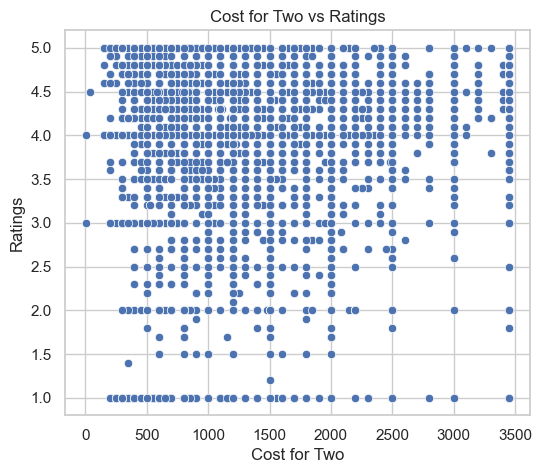

In [42]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df1, x='Cost for Two', y='Ratings')
plt.title("Cost for Two vs Ratings")
plt.show()


The points are widely scattered, indicating no strong linear relationship between cost and ratings.

High ratings (above 4.0) appear across almost all price ranges, showing that both affordable and expensive restaurants can be well-rated.

Some low-rated restaurants exist at different cost levels, suggesting that higher price does not guarantee better ratings.

Overall, the relationship appears weak or slightly positive, but not strongly correlated.

#### Line Plot (Cost for Two vs Ratings)

- A line plot shows the trend or pattern between two numerical variables in a sequential order.

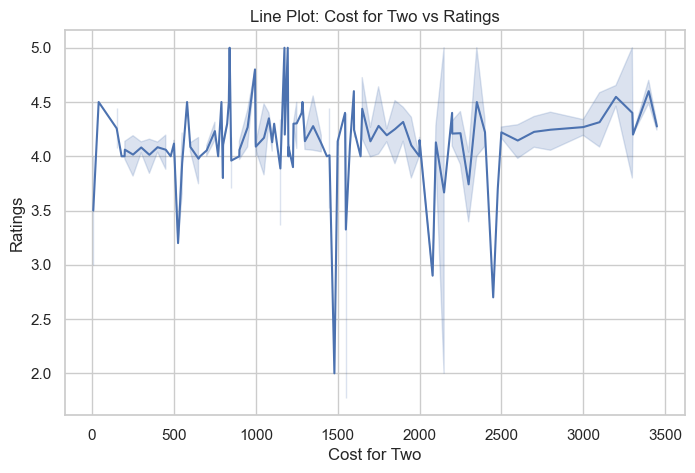

In [43]:
df_sorted = df1.sort_values('Cost for Two')

plt.figure(figsize=(8,5))
sns.lineplot(data=df_sorted, x='Cost for Two', y='Ratings')
plt.title("Line Plot: Cost for Two vs Ratings")
plt.xlabel("Cost for Two")
plt.ylabel("Ratings")
plt.show()

Ratings fluctuate across different cost levels, showing no consistent upward or downward trend.

Most ratings remain around 4.0–4.5, regardless of the cost range.

A few sudden drops in the line represent low-rated restaurants at certain price points.

Overall, the trend suggests that increasing cost does not significantly increase ratings.

### Numerical ↔ Categorical

In [44]:
### Numerical to Categorical
# Average Cost by city
df1.groupby('City')['Cost for Two'].mean().sort_values(ascending=False)

City
Abu-Dhabi             3450.000000
Dubai                 3450.000000
Bengaluru             1779.965358
Delhi-Ncr             1445.878462
Mumbai                1362.919983
Udaipur               1281.730769
Goa                   1246.739130
Pune                  1211.892890
Chennai               1187.670862
Nagpur                1184.121622
Ludhiana              1182.163743
Hyderabad             1146.736247
Visakhapatnam         1144.964029
Jaipur                1144.684592
Agra                  1132.592593
Amritsar              1093.846154
Kolkata               1089.846081
Kochi                 1071.955556
Bhubaneswar           1055.123967
Chandigarh-Tricity    1034.858388
Mysuru                 985.087719
Ranchi                 981.930693
Ahmedabad              968.607372
Indore                 967.627907
Coimbatore             947.450980
Thiruvananthapuram     927.551020
Madurai                878.333333
Lucknow                866.314286
Vadodara               798.423423
Patna    

#### Bar Plot (Average Cost for Two by City)

- A bar plot compares the average values of a numerical variable across different categories.

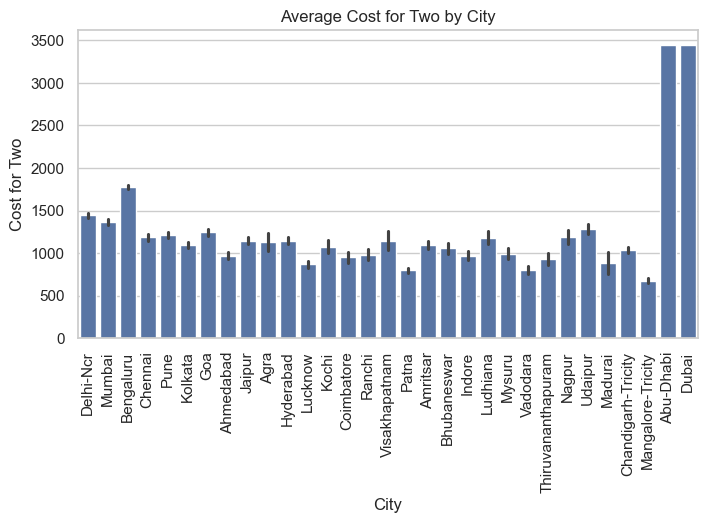

In [45]:
plt.figure(figsize=(8,4))
sns.barplot(data=df1, x='City', y='Cost for Two')
plt.title("Average Cost for Two by City")
plt.xticks(rotation=90)
plt.show()

Dubai and Abu Dhabi show the highest average cost, indicating premium dining markets in these cities.

Among Indian cities, Bengaluru, Mumbai, and Delhi-NCR have relatively higher average costs, reflecting strong metropolitan pricing.

Many tier-2 cities have average costs around ₹800–₹1200, indicating more affordable dining options.

The variation across cities highlights how location significantly influences restaurant pricing.

#### Box Plot (Ratings by City)

- A box plot compares the distribution of numerical values across different categories.

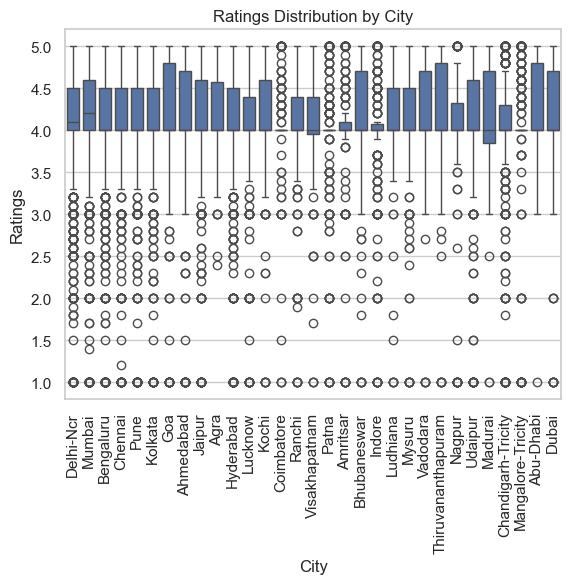

In [10]:
sns.boxplot(data=df1, x='City', y='Ratings')
plt.title("Ratings Distribution by City")
plt.xticks(rotation=90)
plt.show()

Most cities have median ratings around 4.0 to 4.5, indicating generally high customer satisfaction across locations.

The boxes are relatively compact in many cities, showing consistent ratings with limited variation.

Several lower outliers (below 3.0) appear across cities, representing a few poorly rated restaurants.

No city shows extremely low median ratings, suggesting that restaurant quality is fairly stable across regions.

#### Bar Plot (Grouped Average Cost by City)

- A grouped bar plot shows the average numerical value for each category to enable comparison.

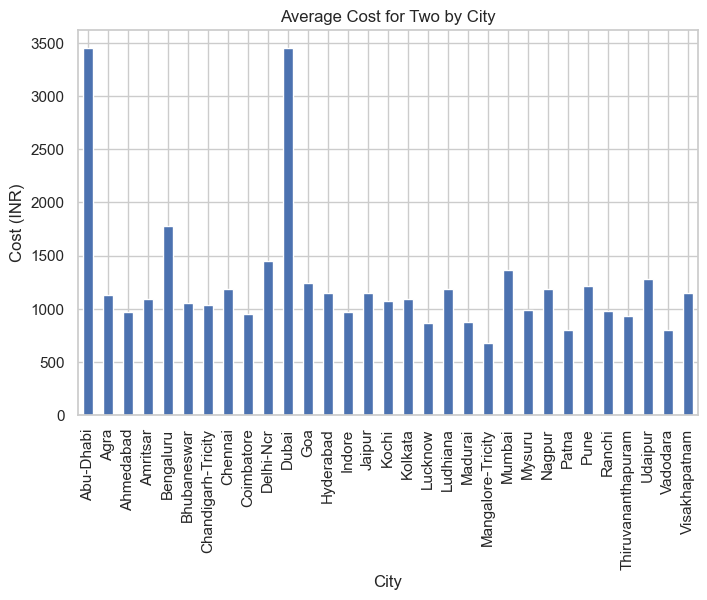

In [47]:
df1.groupby('City')['Cost for Two'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Cost for Two by City")
plt.ylabel("Cost (INR)")
plt.show()

Abu Dhabi and Dubai have the highest average costs, indicating premium international dining markets.

Among Indian cities, Bengaluru shows relatively higher average pricing, followed by other major metro cities.

Many cities have average costs between ₹900 and ₹1200, reflecting affordable to mid-range dining segments.

The variation across cities highlights how economic level and location influence restaurant pricing.

### Categorical - Categorical

#### Crosstab (Cuisine Type vs City)

- A crosstab shows the frequency relationship between two categorical variables.

In [48]:
pd.crosstab(df1['Cuisine Type'], df1['City']).head()

City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
African,0,0,0,0,1,0,2,0,0,2,...,3,0,0,0,0,0,0,0,0,0
All Day Dining,0,0,0,0,3,0,0,0,0,0,...,1,0,0,0,8,0,0,0,0,0
American,0,0,7,2,21,0,13,6,0,9,...,15,3,1,1,5,1,2,1,0,1
Andhra,0,0,0,0,16,0,0,5,0,0,...,0,3,0,0,0,0,0,0,0,2


The table displays how many restaurants of each cuisine type are present in each city.

Some cuisines like American and Andhra appear more frequently in cities like Bengaluru and Delhi-NCR.

Certain cuisine types are limited to specific cities, indicating regional food preferences.

The variation across cities highlights how cultural and local demand influences cuisine distribution.

#### Stacked Bar Plot (Cuisine Type across Cities)

- A stacked bar plot shows the distribution of multiple categories within each group.

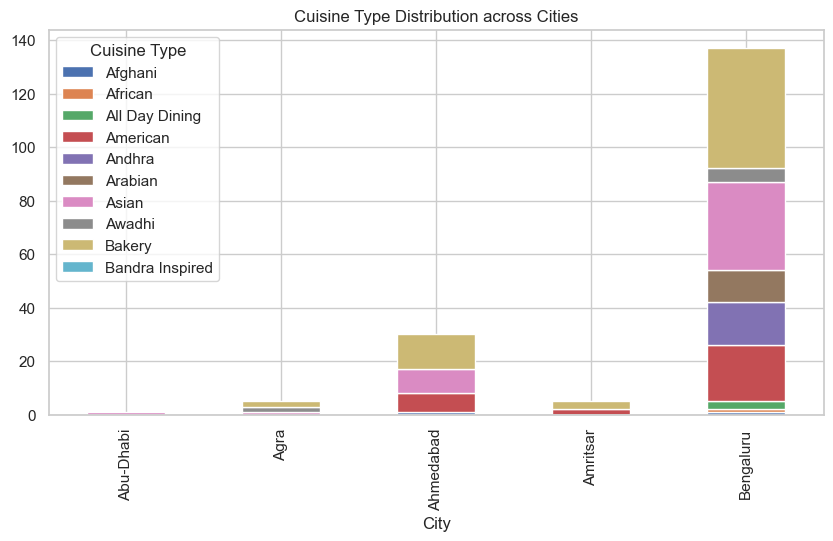

In [49]:
pd.crosstab(df1['City'], df1['Cuisine Type']).iloc[:, :10].head(5).plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),
    
)

plt.title("Cuisine Type Distribution across Cities")
# plt.legend().set_visible(False)
plt.show()


Bengaluru shows the highest overall count of different cuisine types, indicating a diverse food culture.

Ahmedabad also has a noticeable distribution of multiple cuisines, but lower compared to Bengaluru.

Cities like Abu Dhabi, Agra, and Amritsar show limited cuisine variety in comparison.

The stacked structure clearly shows how cuisine diversity varies from city to city, reflecting regional demand and urbanization level.

#### Count Plot (Top 5 Cuisines across Top 5 Cities)

- A grouped count plot compares the frequency of categories across different groups.

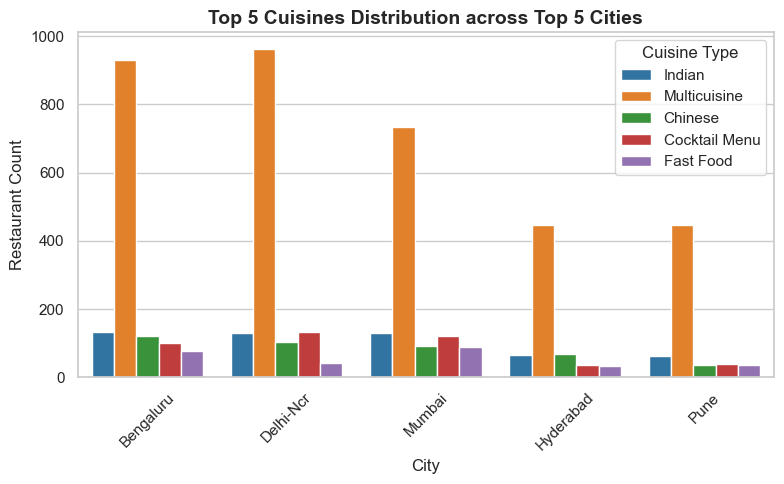

In [50]:
top_cities = df1["City"].value_counts().index[:10]
top_cuisines = df1['Cuisine Type'].value_counts().index[:5]
# filtered_df = df1[df1['Cuisine Type'].isin(top_cuisines)]
filtered_df = df1[df1["City"].isin(top_cities) & df1["Cuisine Type"].isin(top_cuisines)]

plt.figure(figsize=(8,5))

sns.countplot(
    data=filtered_df.reset_index(drop=True),
    x='City',
    hue='Cuisine Type',  # differentiate cuisines
    order=df1['City'].value_counts().head(5).index,
    palette='tab10'
)
plt.title("Top 5 Cuisines Distribution across Top 5 Cities", fontsize=14, weight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Restaurant Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Multicuisine clearly dominates in all top cities, especially in Delhi-NCR and Bengaluru, showing strong demand for diverse food options.

Indian and Chinese cuisines also have consistent presence across major metro cities.

Mumbai and Delhi-NCR show relatively higher counts across multiple cuisine types, indicating greater food diversity.

Hyderabad and Pune have comparatively lower counts, suggesting a smaller but still active restaurant market.


#### Categorical - Categorical

#### Pivot Table (City × Cuisine)

In [51]:
import pandas as pd

# Crosstab with mean Ratings
crosstab_ratings = pd.crosstab(
    index=df1['Cuisine Type'],  # rows
    columns=df1['City'],        # columns
    values=df1['Ratings'],      # numeric values to aggregate
    aggfunc='mean'              # aggregation function
)

crosstab_ratings


City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


In [52]:
# Convert to string (handles NaN or list-like entries)
df1['Cuisine Type'] = df1['Cuisine Type'].astype(str)

# Remove brackets, quotes, and backslashes
df1['Cuisine Type'] = (
    df1['Cuisine Type']
    .str.replace(r"[\[\]'\"\\]", '', regex=True) # remove [ ] ' " \
    .str.strip()
)
df1['Cuisine Type'] = df1['Cuisine Type'].apply(lambda x: [i.strip() for i in x.split(',') if i.strip() != ''])

# Explode the list to create one row per cuisine
df1 = df1.explode('Cuisine Type')

# Now build pivot table safely
pivot_table = pd.pivot_table(
    df1,
    values='Ratings',
    index='Cuisine Type',
    columns='City',
    aggfunc='mean'
)
pivot_table

City,Abu-Dhabi,Agra,Ahmedabad,Amritsar,Bengaluru,Bhubaneswar,Chandigarh-Tricity,Chennai,Coimbatore,Delhi-Ncr,...,Mumbai,Mysuru,Nagpur,Patna,Pune,Ranchi,Thiruvananthapuram,Udaipur,Vadodara,Visakhapatnam
Cuisine Type,,,,,,,,,,,,,,,,,,,,,
Afghani,NaN,NaN,4.300000,NaN,4.200000,NaN,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
African,NaN,NaN,NaN,NaN,4.300000,NaN,4.600000,NaN,NaN,4.200000,...,4.566667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
All Day Dining,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,NaN,NaN,...,4.600000,NaN,NaN,NaN,4.062500,NaN,NaN,NaN,NaN,NaN
American,NaN,NaN,4.457143,3.9,4.261905,NaN,4.023077,4.100000,NaN,4.233333,...,4.280000,3.333333,4.0,5.0,4.520000,4.0,4.7,4.1,NaN,4.00
Andhra,NaN,NaN,NaN,NaN,4.106250,NaN,NaN,4.360000,NaN,NaN,...,NaN,3.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vegan,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,5.000000,NaN,4.433333,...,4.000000,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,NaN
Vietnamese,NaN,NaN,NaN,NaN,4.600000,NaN,NaN,NaN,NaN,4.600000,...,4.400000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,NaN


### Continuous vs Continuous 

In [53]:
df1[['Cost for Two', 'Ratings']].corr()

,Cost for Two,Ratings
Cost for Two,1.000000,0.074043
Ratings,0.074043,1.000000


#### Scatter Plot (Cost vs Ratings)

- A scatter plot is used to examine the relationship between two continuous variables.

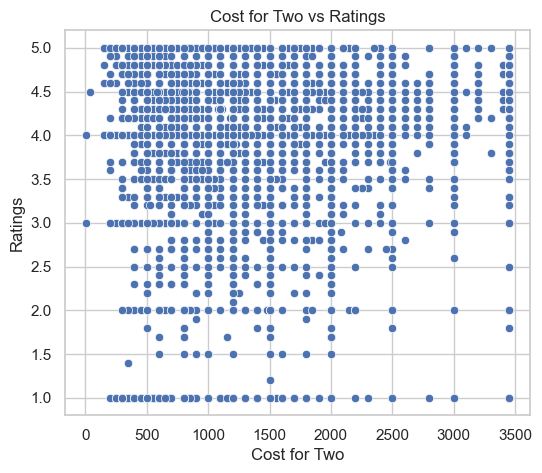

In [12]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Cost for Two', y='Ratings', data=df1)
plt.title("Cost for Two vs Ratings")
plt.show()

The points are widely spread, showing no strong linear relationship between cost and ratings.

High ratings (above 4.0) are seen across both low and high price ranges, indicating that expensive restaurants are not always better rated.

Some low-rated restaurants exist at various cost levels, suggesting that price does not guarantee quality.

Overall, the relationship appears weak or slightly positive but not strongly correlated.

#### Pair Plot (Cost for Two & Ratings)

- A pair plot visualizes the relationship and distribution of multiple numerical variables together.

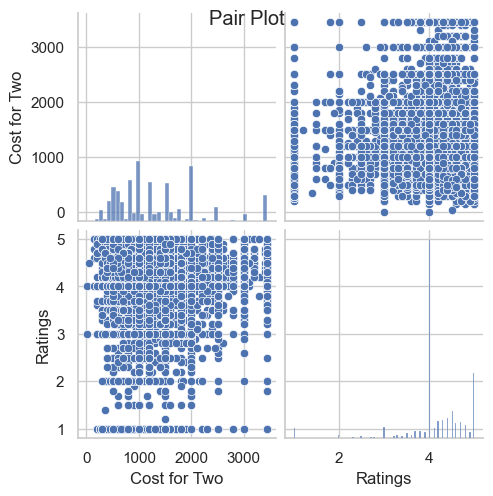

<Figure size 800x400 with 0 Axes>

In [54]:
sns.pairplot(df1[['Cost for Two', 'Ratings']])
plt.suptitle("Pair Plot")
plt.figure(figsize=(8,4))
plt.show()

The diagonal plots show the individual distribution of Cost for Two and Ratings separately.

The scatter plots indicate a weak relationship between cost and ratings.

Most ratings are concentrated between 4.0 and 4.5, regardless of price range.

The spread of cost values is wide, but ratings remain relatively consistent, showing price does not strongly impact ratings.

#### Heatmap (Correlation Matrix)

- A correlation heatmap visually represents the strength and direction of relationships between numerical variables.

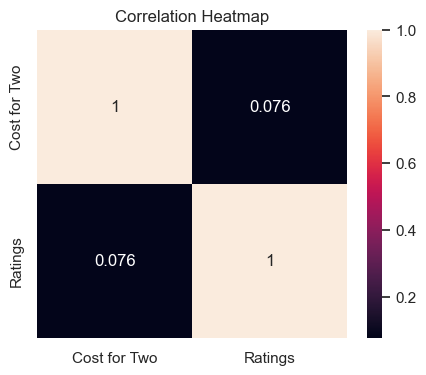

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(df1[['Cost for Two', 'Ratings']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

The correlation value between Cost for Two and Ratings is 0.074, which is very close to 0.

This indicates a very weak positive relationship between price and ratings.

The value is too small to suggest any meaningful linear relationship.

This confirms that higher restaurant cost does not strongly influence customer ratings.